# Logistic Regression

## Outline

1. Introduction
2. Logistic Regression
3. Decision Boundary
4. Cost Function
5. Gradient Descent
6. Model Training and Prediction
7. Closing Remarks

## 1. Introduction

So far, we have discussed regression tasks that map features to a continuous target. For example, in the univariate linear regression notebook, our model learned to map study hours to exam scores.

Another category of machine learning tasks is classification. Classification models also take features as input, but instead of predicting a continuous value, they assign an example to a category.

In this notebook, we will discuss binary classification using logistic regression. Binary classification assigns each example to either the positive class, represented by 1, or the negative class, represented by 0.

You might think that we could use linear regression and apply a threshold to its continuous predictions. This is a reasonable first idea, but linear regression is not well suited for binary classification. Outliers can strongly affect the fitted regression line and therefore shift the resulting decision boundary. In addition, linear regression predictions are not restricted to the range from 0 to 1. Logistic regression addresses these problems and is specifically designed for binary classification.

> **Note**
>
> Throughout this notebook, we will refer to the implementation of logistic regression. The complete implementation can be found in the `src/ml_from_scratch` directory.
>
> If you are interested in the behavior of the individual functions, you may also want to explore the unit tests in the `tests` directory. Besides verifying correctness, they provide additional examples of how the implementation is intended to be used.

Run the code cell below to load the required dependencies and generate the dataset used throughout this notebook.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from utils.helpers import (
    generate_logistic_regression_dataset,
)

from utils.plotting import (
    plot_binary_classes,
    plot_sigmoid_function,
)

from ml_from_scratch.logistic_regression import (
    sigmoid
)

X, y = generate_logistic_regression_dataset()

The dataset follows the same student-performance theme as the previous notebooks. It contains $m = 40$ training examples with two features:

- $x_{1}$: study hours
- $x_{2}$: completed practice tests

This time, the target $y$ is binary:

- $y = 1$: exam passed
- $y = 0$: exam failed

Before moving on to the next chapter, run the following code cell to visualize the dataset and examine how the two classes are distributed.

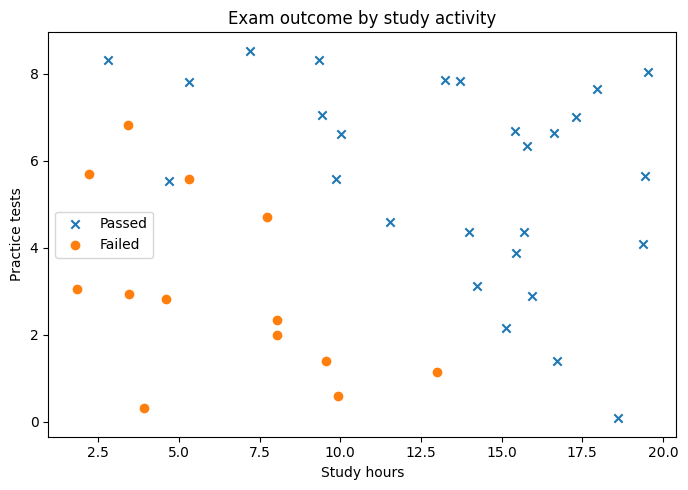

In [2]:
feature_names = ["Study hours", "Practice tests"]

plot_binary_classes(X, y, feature_names)

plt.show()

Study hours range from 1 to 20, while the number of completed practice tests ranges from 0 to 10. Of the 40 students, 27 passed the exam and 13 failed.

## 2. Logistic Regression

In contrast to the unrestricted outputs of linear regression, logistic regression produces values between 0 and 1. These values can be interpreted as the estimated probabilities that an example belongs to the positive class, represented by $y = 1$.

The function used to restrict the model output to this range is the sigmoid function. If you look at the shape of the function below, you will quickly see where its name comes from.

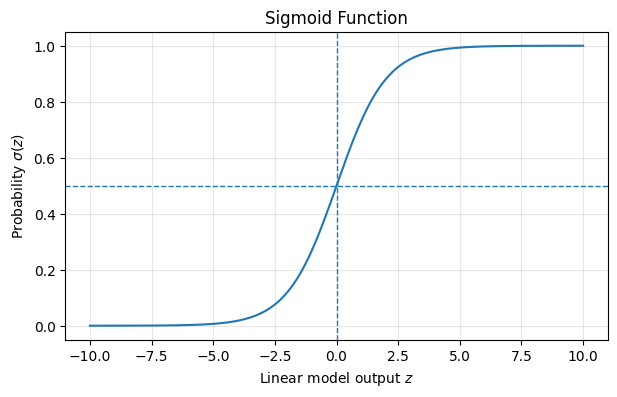

In [4]:
z = np.linspace(-10, 10, 200)
probabilities = sigmoid(z)

plot_sigmoid_function(z, probabilities)

plt.show()


As shown in the plot, the sigmoid function has an S-shaped curve. It is defined as

$$
g(z) = \frac{1}{1 + e^{-z}}.
$$

The denominator contains the exponential term $e^{-z}$, where Euler's number $e$ is the base and $-z$ is the exponent. In the Python implementation, this term is computed using NumPy's `np.exp(-z)`. The function works element-wise, allowing it to process either a single $z$-value or an array of values.

In practice, $z$ is first computed as a linear combination of the input features plus a bias term:

$$
z = \mathbf{w}^{T}\mathbf{x} + b.
$$

The result is then passed to the sigmoid function:

$$
f_{\mathbf{w},b}(\mathbf{x}) = g(\mathbf{w}^{T}\mathbf{x} + b).
$$

Logistic regression therefore performs the calculation in two steps. First, it computes the linear model output $z$. It then applies the sigmoid function to transform this value into an estimated probability.

> **Note:** The linear model output $z$ is often called a *logit*. This is why the implementation uses a function named `compute_logits()`. When $X$ contains multiple training examples, the function returns one logit for each example.

To make this calculation more concrete, consider a student who studied for 10 hours and completed 5 practice tests. The feature vector is therefore

$$
\mathbf{x}
=
\begin{bmatrix}
10 \\
5
\end{bmatrix}.
$$

For illustration, assume that the model parameters are

$$
\mathbf{w}
=
\begin{bmatrix}
0.5 \\
0.9
\end{bmatrix}
\qquad \text{and} \qquad
b = -8.
$$

The linear model output is then

$$
\begin{aligned}
z
&= \mathbf{w}^{T}\mathbf{x} + b \\
&= 0.5 \cdot 10 + 0.9 \cdot 5 - 8 \\
&= 1.5.
\end{aligned}
$$

This value is then passed to the sigmoid function:

$$
\begin{aligned}
g(1.5)
&= \frac{1}{1 + e^{-1.5}} \\
&\approx 0.818.
\end{aligned}
$$

The model therefore estimates a probability of approximately 81.8% that this student belongs to the positive class and passes the exam. In more formal terms, we can write

$$
P(y = 1 \mid \mathbf{x}) \approx 0.818,
$$

where the vertical bar is read as “given.” The expression therefore means: “The probability that $y = 1$, given the feature vector $\mathbf{x}$.”

You might wonder whether $z = \mathbf{w}^{T}\mathbf{x} + b$ is itself a linear regression model because the equation looks familiar. However, $z$ is simply a linear combination of the input features plus a bias term. The same linear expression is used in linear regression, but it can also serve as one component of other models. In logistic regression, the linear output is passed through the sigmoid function instead of being used directly as the prediction.

Besides its S-shape, the plot shows that the sigmoid function is bounded between 0 and 1. The endpoints are not included, meaning that the output approaches but never mathematically reaches either value.

When $z$ is very large and negative, the exponent $-z$ becomes very large and positive. Therefore, $e^{-z}$ and the denominator become very large:

$$
g(z) = \frac{1}{1 + e^{-z}} \approx 0.
$$

On the other hand, when $z$ is very large and positive, $-z$ becomes very negative and $e^{-z}$ approaches 0. The denominator therefore approaches 1:

$$
g(z) = \frac{1}{1 + e^{-z}} \approx 1.
$$

Another important point occurs at $z = 0$. Since $e^{0} = 1$, we obtain

$$
g(0) = \frac{1}{1 + 1} = \frac{1}{2}.
$$

The sigmoid function therefore returns exactly $0.5$ when the linear model output is zero.

One important fact is that the sigmoid output is not yet a binary class prediction. A probability threshold is still required to assign an example to either the negative class $y = 0$ or the positive class $y = 1$. We will discuss this decision rule in the next chapter.

## 3. Decision Boundary

## 4. Cost Function

## 5. Gradient Descent

## 6. Model Training and Prediction

## 7. Closing Remarks